# **Lab 4.2 NN MLP and CNN**

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset, random_split
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import ImageGrid
from collections import Counter
import os
from sklearn.metrics import confusion_matrix

Complete the `load_data()` function that loads the image using `ImageFolder()` with the specific `transforms.compose()` provided below.
`load_data()` will return `DataLoader()` and print the information about the Dataset.
This function must load only a pair of classes from the entire dataset.
Please ensure that the final image is in grayscale and has a size of 28x28.

`transforms.Compose()` :
- `transforms.Resize(32)`
- `transforms.ToTensor()`
- `transforms.Pad()`
- `transforms.RandomRotation(45),`
- `transforms.CenterCrop(28)`

Resource : [`transforms.Compose()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Compose.html#compose), [`torchvision.transforms v1`](<https://pytorch.org/vision/stable/transforms.html#v1-api-reference:~:text=custom)%20tv_tensor%20type.-,V1%20API%20Reference,-Geometry>)

In [6]:

def load_data(path, class_names, print_number=True):
    
    ### START CODE HERE ###
    transform = transforms.Compose([
        transforms.Resize(32),
        transforms.Pad(padding=10, fill=255),
        transforms.RandomRotation(45, fill=255),
        transforms.CenterCrop(28),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor()
    ])
    
    dataset = ImageFolder(path, transform=transform)
    indices = [i for i, (_, label) in enumerate(dataset) if label in class_names]
    filtered_dataset = Subset(dataset, indices)
    
    train_size = int(0.8 * len(filtered_dataset))
    test_size = len(filtered_dataset) - train_size
    train_dataset, test_dataset = random_split(filtered_dataset, [train_size, test_size])
    
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=False)
        
    train_indices = train_dataset.indices
    train_labels = [dataset.samples[i][1] for i in train_indices]
    train_counts = Counter(train_labels)
    
    test_indices = test_dataset.indices
    test_labels = [dataset.samples[i][1] for i in test_indices]
    test_counts = Counter(test_labels)
    
    if print_number:
        print("📃Train Dataset:")
        for cls in class_names:
            print(f"Number of images in class {cls}: {train_counts[cls]}")
        print("Number of training samples:", len(train_dataset))
        
        print("📃Test Dataset:")
        for cls in class_names:
            print(f"Number of images in class {cls}: {test_counts[cls]}")
        print("Number of testing samples:", len(test_dataset))

    ### END CODE HERE ###

    return train_loader, test_loader

Use your `load_data()` function to load the dataset in the cell below. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

```
📃Train Dataset:
	Number of images in class 0: 313
	Number of images in class 1: 308
	Number of training samples: 621

📃Test Dataset:
	Number of images in class 0: 75
	Number of images in class 1: 81
	Number of testing samples: 156
```


![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/03.png?raw=true)

</details>

📃Train Dataset:
Number of images in class 0: 314
Number of images in class 1: 307
Number of training samples: 621
📃Test Dataset:
Number of images in class 0: 74
Number of images in class 1: 82
Number of testing samples: 156


c:\Users\asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([28, 28, 1])


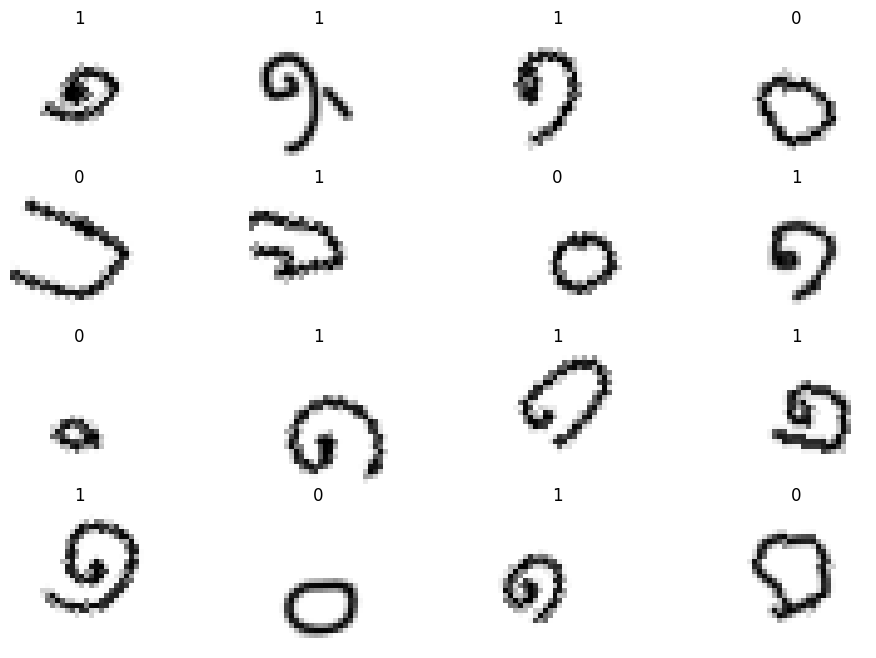

In [ ]:
### START CODE HERE ###

class_names = (0, 1)
train_loader, test_loader = load_data("thai-handwriting-number", class_names)

first_batch = next(iter(train_loader))

images, labels = first_batch

fig = plt.figure(figsize=(20, 8))
grid = ImageGrid(fig, rect=111 , nrows_ncols=(4, 4), axes_pad=(1, 0.2))

for i, ax in enumerate(grid):
    channel_last = images[i].permute(1, 2, 0)
    im = ax.imshow(channel_last, cmap="gray")
    ax.set_title(labels[i].item())
    ax.set_axis_off()
    
print(channel_last.shape)

plt.show()

### END CODE HERE ###

In [9]:
### START CODE HERE ###
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(in_features= 28 * 28,out_features= 1)
        self.sigmoid = nn.Sigmoid()

    def get_features(self,x):
        input_layer = x
        
        x = self.flatten(x)
        flatten_layer = x
        
        x = self.fc(x)
        fully_connected_layer = x
        
        x = self.sigmoid(x)
        sigmoid_layer = x
        
        return input_layer, flatten_layer, fully_connected_layer, sigmoid_layer

    def forward(self, x):
        x = self.get_features(x)[-1]
        return x
    
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(in_features = 28 * 28, out_features = 16)
        self.sigmoid1 = nn.Sigmoid()
        
        self.fc2 = nn.Linear(in_features = 16, out_features = 1)
        self.sigmoid2 = nn.Sigmoid()
    
    def get_features(self,x):
        input_layer = x
        
        x = self.flatten(x)
        flatten_layer = x
        
        x = self.fc1(x)
        fully_connected_1_layer = x
        
        x = self.sigmoid1(x)
        sigmoid_1_layer = x
        
        x = self.fc2(x)
        fully_connected_2_layer = x
        
        x = self.sigmoid2(x)
        sigmoid_2_layer = x
        
        return input_layer, flatten_layer, fully_connected_1_layer, sigmoid_1_layer, fully_connected_2_layer, sigmoid_2_layer

    def forward(self, x):
        x = self.get_features(x)[-1]
        return x
    
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3)
        self.relu1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.relu2 = nn.ReLU()
        
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(32 * 24 * 24, 128)
        self.relu3 = nn.ReLU()
        
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
        
    def get_features(self,x):
        input_layer = x
            
        x = self.conv1(x)
        convolution_1_layer = x
        
        x = self.relu1(x)
        relu_1_layer = x
        
        x = self.conv2(x)
        convolution_2_layer = x
        
        x = self.relu2(x)
        relu_2_layer = x
        
        x = self.flatten(x)
        flatten = x
                
        x = self.fc1(x)
        fully_connected_1_layer = x
        
        x = self.relu3(x)
        relu_3_layer = x
        
        x = self.fc2(x)
        fully_connected_2_layer = x
        
        x = self.sigmoid(x)
        sigmoid_layer = x
        
        return input_layer, convolution_1_layer, relu_1_layer, convolution_2_layer, relu_2_layer, flatten, fully_connected_1_layer, relu_3_layer, fully_connected_2_layer, sigmoid_layer

    def forward(self, x):
        x = self.get_features(x)[-1]
        return x

### END CODE HERE ###

Complete the function below. This function will be used to display the feature map from the models at every epoch on TensorBoard.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output that will be display on TensorBoard</b>
</font>
</summary>

- The output should resemble this, but not be identical
- `NN()`<br>
![image.png](https://raw.githubusercontent.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/refs/heads/main/Lab4_NN-and-CNN/assets/04.png)
- `MLP()`<br>
![image-2.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/05.png?raw=true)
- `CNN()`<br>
![image-3.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/06.png?raw=true)
</details>

In [7]:
def show_featuremaps(feats: torch.Tensor):
    feats = [feat.detach().cpu() for feat in feats]
    num_featmaps = len(feats)
    fig, axes = plt.subplots(1, num_featmaps, figsize=(12, 4))

    for i in range(num_featmaps):
        f = feats[i]
            
        if f.shape == (1, 1):
            axes[i].imshow(f, cmap='viridis', aspect='equal', vmax=1, vmin=0)
            
        elif f.ndim == 2:
            f = f.T
            axes[i].imshow(f, cmap='viridis', aspect='auto')
            
        else:
            f = f.squeeze(0)
            f= f.reshape(f.shape[0]*f.shape[1], f.shape[2], 1)
            axes[i].imshow(f, cmap='viridis', aspect='equal')

        
        axes[i].axis('off')

    return fig


**Create Models**
1. **NN (Neural Network)**:
- **Input**: 28x28 grayscale images (1 channel)
- **Architecture**: Single fully connected layer with sigmoid activation
- **Output**: Single neuron output with sigmoid activation
- **Description**: This is a simple feedforward neural network with a single fully connected layer. It takes input images, flattens them, passes through a fully connected layer, and applies sigmoid activation to produce the output.

2. **MLP (Multi-Layer Perceptron)**:
- **Input**: 28x28 grayscale images (1 channel)
- **Architecture**: Two fully connected layers with sigmoid activations
- **Output**: Single neuron output with sigmoid activation
- **Description**: This is a multi-layer perceptron with two fully connected layers. After flattening the input images, it passes through the first fully connected layer with sigmoid activation, followed by the second fully connected layer with sigmoid activation, producing the output.

3. **CNN (Convolutional Neural Network)**:
- **Input**: 28x28 grayscale images (1 channel)
- **Architecture**: Two convolutional layers with ReLU activations, followed by two fully connected layers with ReLU activations
- **Output**: Single neuron output with sigmoid activation
- **Description**: This is a convolutional neural network with two convolutional layers followed by two fully connected layers. It applies convolutional operations with ReLU activations, followed by flattening the output and passing through fully connected layers with ReLU activations. Finally, it produces a single neuron output with sigmoid activation.


Every model should have a `get_features()` method that returns the result from all layers.

TensorBoard 101

Complete the `train()` function in the cell below. This function should evaluate the model at every epoch, log the training loss/accuracy, test loss/accuracy, and display the feature map from all layers of the model at every epoch on TensorBoard. Additionally, it should save the model at the last epoch.

Resource : [PyTorch Training loop](<https://pytorch.org/tutorials/beginner/introyt/trainingyt.html#:~:text=%3D0.9)-,The%20Training%20Loop,-Below%2C%20we%20have>), [TensorBoard](https://pytorch.org/docs/stable/tensorboard.html)

<details>
<summary>
<font size="3" color="orange">
<b>Expected output that will be display on TensorBoard</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://raw.githubusercontent.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/refs/heads/main/Lab4_NN-and-CNN/assets/07.png)

![image-2.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/08.png?raw=true)
</details>

In [8]:
def train(class_names,model,opt,loss_fn,train_loader,test_loader,epochs=10,writer=None,checkpoint_path=None,device='cpu'):
    ### START CODE HERE ###
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward
            outputs = model(images)
            
            remapped_labels = (labels == labels.max()).float()
            loss = loss_fn(outputs.squeeze(), remapped_labels)

            # Backward
            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item() * images.size(0)
            preds = (outputs.squeeze() > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

        # Evaluation
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                remapped_labels = (labels == labels.max()).float()
                loss = loss_fn(outputs.squeeze(), remapped_labels)

                test_loss += loss.item() * images.size(0)
                preds = (outputs.squeeze() > 0.5).float()
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)

        test_loss /= test_total
        test_acc = test_correct / test_total

        if writer:
            writer.add_scalar("Loss/Train", train_loss, epoch)
            writer.add_scalar("Accuracy/Train", train_acc, epoch)
            writer.add_scalar("Loss/Test", test_loss, epoch)
            writer.add_scalar("Accuracy/Test", test_acc, epoch)

            sample_img, _ = next(iter(test_loader))
            sample_img = sample_img[0].unsqueeze(0).to(device)

            with torch.no_grad():
                feats = model.get_features(sample_img)
                fig = show_featuremaps(feats)
                writer.add_figure("FeatureMaps", fig, global_step=epoch)

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    # Save model
    if checkpoint_path:
        torch.save(model.state_dict(), checkpoint_path)

    ### END CODE HERE ###

Use your `train()` function to train all types of models with all combinations of numbers that you've obtained.

In [11]:
def generate_class_pair():
    class_pairs = []
    for i in range(10):
        for j in range(i + 1, 10):
            class_pairs.append((i, j))
    return class_pairs
class_pairs = generate_class_pair()

In [ ]:
### START CODE HERE ###
models = ['NN', 'MLP', 'CNN']

for (cl1, cl2) in class_pairs:
    
    print(cl1, cl2)
    
    train_loader, test_loader = load_data("thai-handwriting-number", (cl1, cl2))
    
    print("load data success")
    
    for model in models:
        if model == 'NN':
            train_model = NN()
        elif model == 'MLP':
            train_model = MLP()
        else:
            train_model = CNN()
            
        save_path = f'{cl1}_{cl2}/{model}'
        writer = SummaryWriter(log_dir=f"./runs/{save_path}")
        
        optimizer = optim.Adam(train_model.parameters(), lr=0.001)
        loss_fn = nn.BCELoss()

        save_checkpoint_path = f'checkpoints/{cl1}_{cl2}/{model}.pth'

        os.makedirs(os.path.dirname(save_checkpoint_path), exist_ok=True)
        
        train(
            class_names=(cl1, cl2),
            model=train_model,
            opt=optimizer,
            loss_fn=loss_fn,
            train_loader=train_loader,
            test_loader=test_loader,
            epochs=10,
            writer=writer,
            checkpoint_path=save_checkpoint_path,
            device='cuda' if torch.cuda.is_available() else 'cpu'
        )
        
        print("finish training a model")

writer.close()

# tensorboard --logdir=runs
### END CODE HERE ###

0 1
📃Train Dataset:
Number of images in class 0: 308
Number of images in class 1: 313
Number of training samples: 621
📃Test Dataset:
Number of images in class 0: 80
Number of images in class 1: 76
Number of testing samples: 156
load data success
Epoch [1/10] Train Loss: 0.7662, Train Acc: 0.5443 | Test Loss: 0.6803, Test Acc: 0.5577
Epoch [2/10] Train Loss: 0.6742, Train Acc: 0.5926 | Test Loss: 0.6544, Test Acc: 0.6474
Epoch [3/10] Train Loss: 0.6524, Train Acc: 0.6377 | Test Loss: 0.6262, Test Acc: 0.7244
Epoch [4/10] Train Loss: 0.6314, Train Acc: 0.6876 | Test Loss: 0.6096, Test Acc: 0.7372
Epoch [5/10] Train Loss: 0.6156, Train Acc: 0.6828 | Test Loss: 0.5923, Test Acc: 0.6795
Epoch [6/10] Train Loss: 0.5991, Train Acc: 0.7053 | Test Loss: 0.5858, Test Acc: 0.6859
Epoch [7/10] Train Loss: 0.6141, Train Acc: 0.6441 | Test Loss: 0.5713, Test Acc: 0.7500
Epoch [8/10] Train Loss: 0.5842, Train Acc: 0.7069 | Test Loss: 0.5664, Test Acc: 0.6731
Epoch [9/10] Train Loss: 0.5627, Train Acc

Try to load the weights into the model and the confusion matrix for each model with every combination of numbers that you've obtained, as shown in the expected output.


<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical
This is just an example of NN. You should have three models: NN, MLP, and CNN, with one model per plot.

![image.png](https://raw.githubusercontent.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/refs/heads/main/Lab4_NN-and-CNN/assets/09.png)

</details>

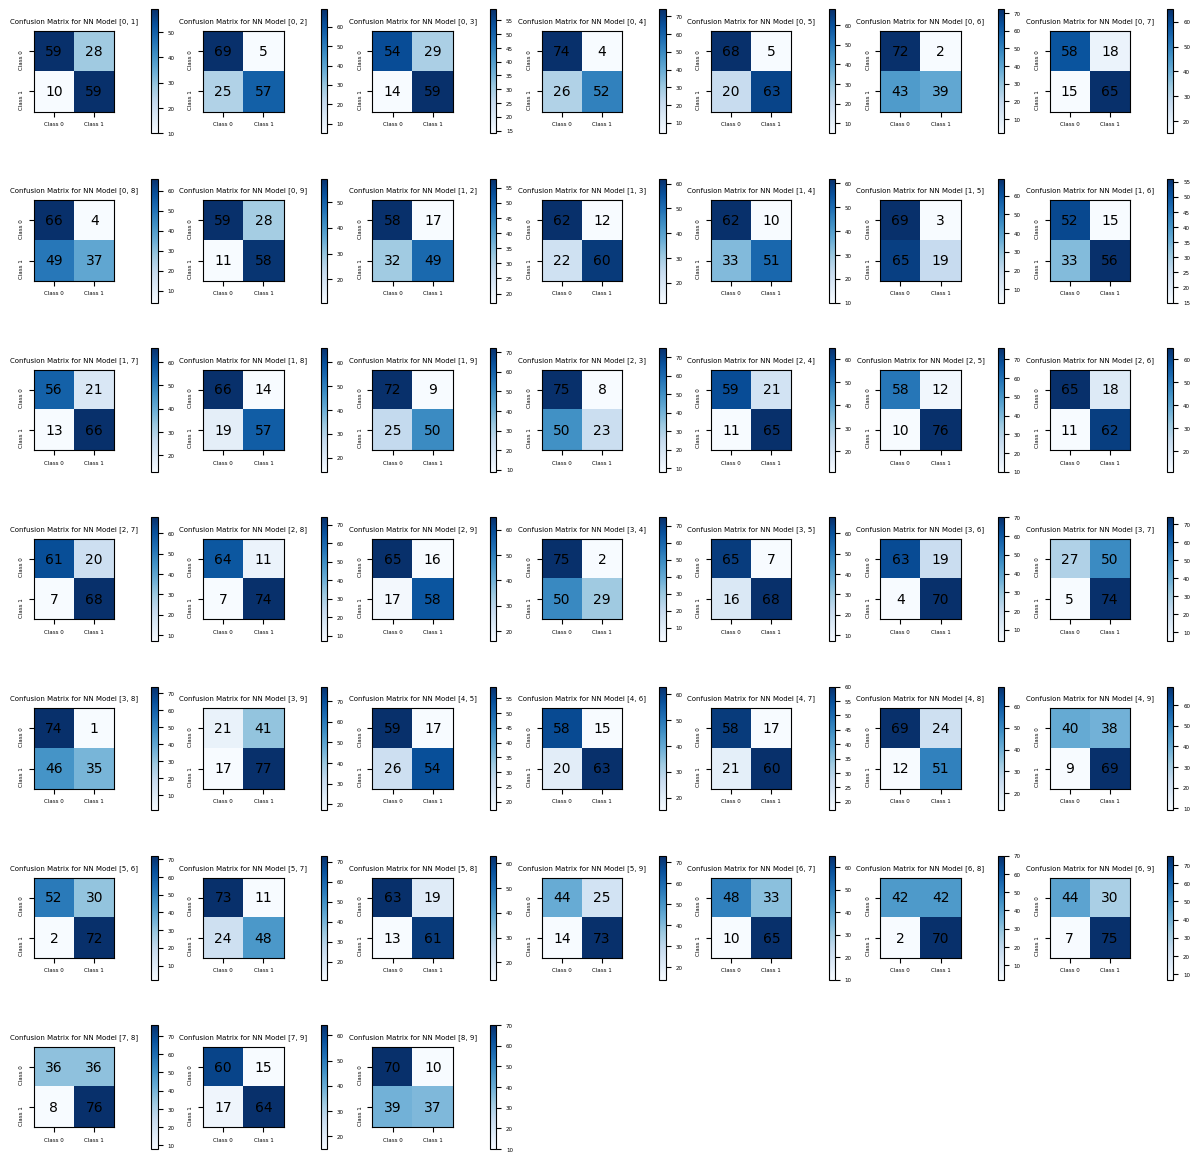

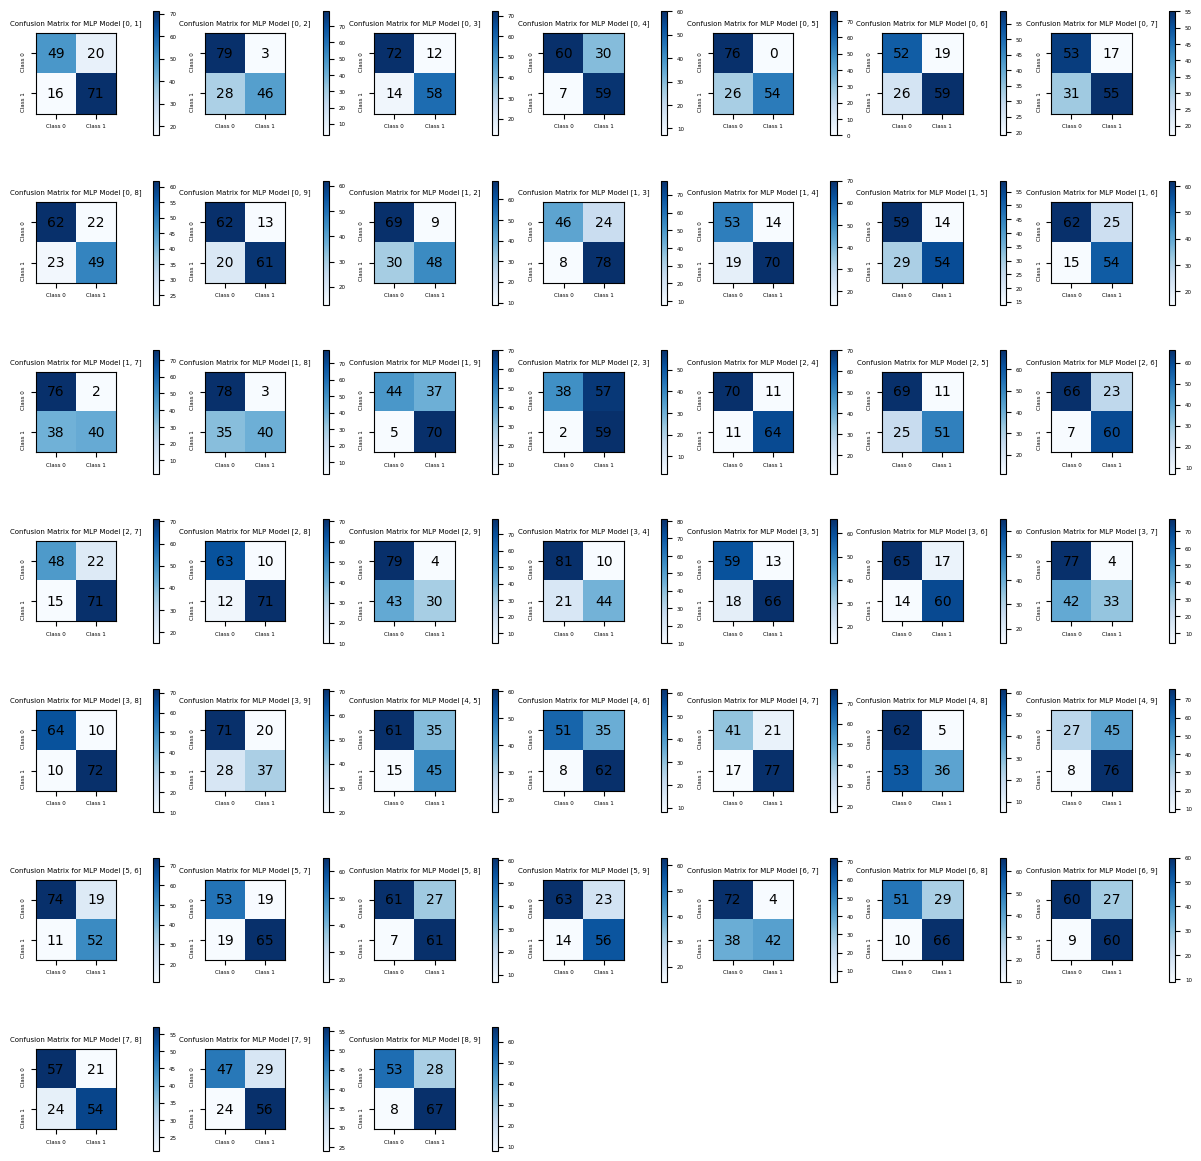

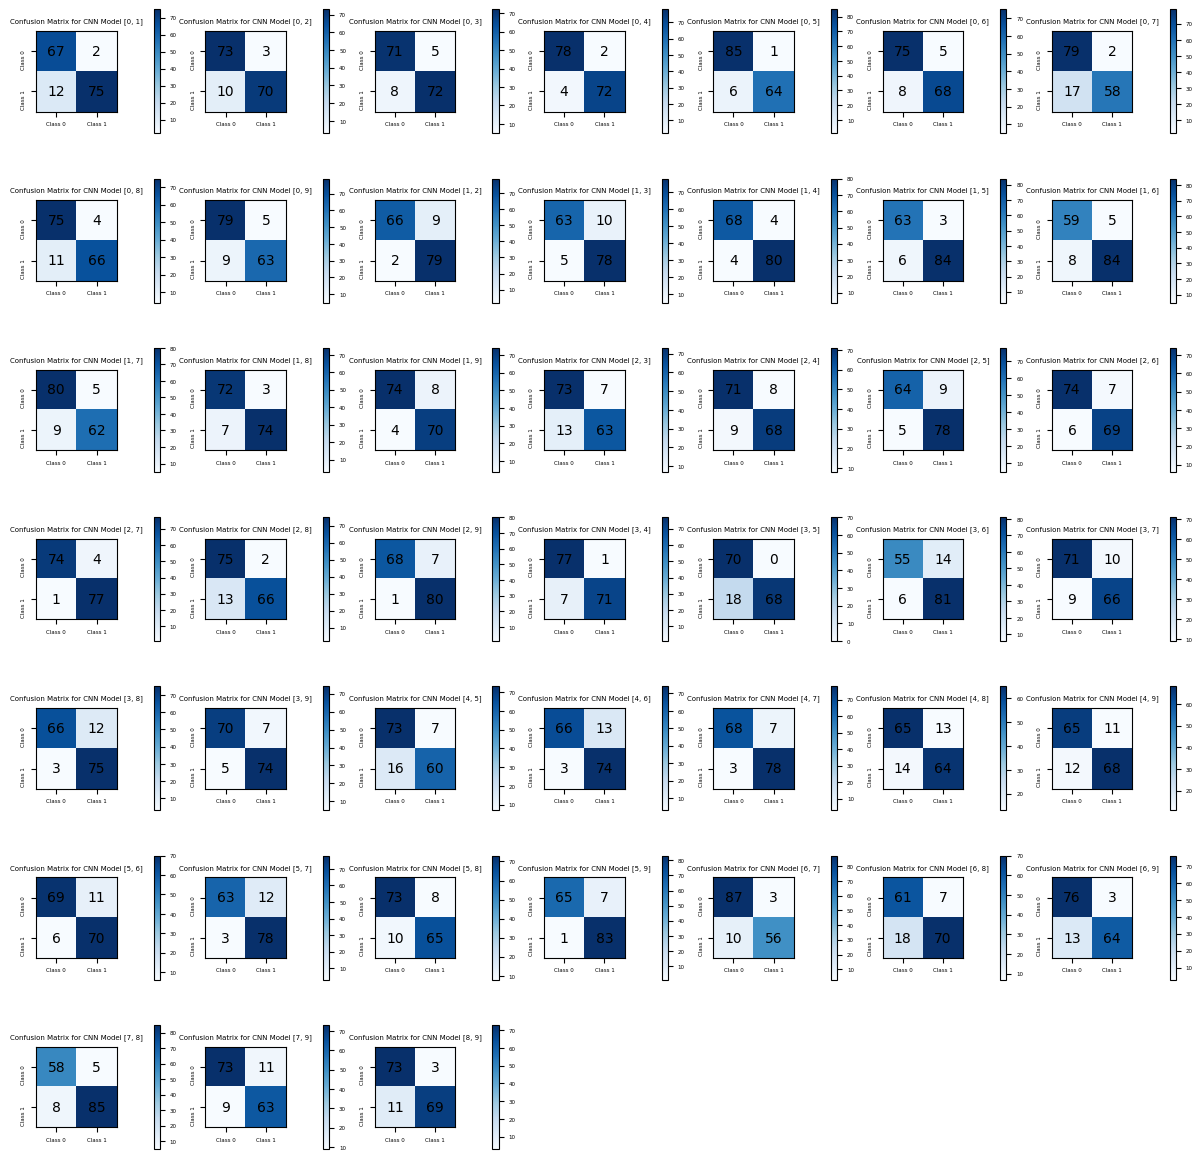

In [12]:
### START CODE HERE ###
def create_confusion_matrix(model, dataloader, class_names):
    y_true = []
    y_pred = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.cuda() if torch.cuda.is_available() else inputs
            labels = [class_names.index(label) for label in labels]
            labels = torch.tensor(labels)

            outputs = model(inputs)
            preds = (outputs.squeeze() > 0.5).long().cpu()

            y_true.extend(labels)
            y_pred.extend(preds)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return confusion_matrix(y_true, y_pred, labels=[0, 1])

def create_confusion_matrix_model(model_name):
    fig, axes = plt.subplots(7, 7, figsize=(12, 12))
    plt.subplots_adjust(hspace=0.5)
    axes = axes.flatten()

    for idx, (cl1, cl2) in enumerate(class_pairs):
        if model_name == 'NN':
            model = NN()
        elif model_name == 'MLP':
            model = MLP()
        else:
            model = CNN()
        weight_path = f'checkpoints/{cl1}_{cl2}/{model_name}.pth'
        model.load_state_dict(torch.load(weight_path))
        model.eval()

        train_loader, test_loader = load_data("thai-handwriting-number", (cl1, cl2), False)

        cm = create_confusion_matrix(model, test_loader, (cl1, cl2))
        ax = axes[idx]
        im = ax.imshow(cm, cmap='Blues')
        ax.set_title(f'Confusion Matrix for {model_name} Model [{cl1}, {cl2}]', fontsize=5)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Class 0", "Class 1"], fontsize=4)
        ax.set_yticklabels(["Class 0", "Class 1"], fontsize=4, rotation=90)
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
        cbar =  fig.colorbar(im, ax=ax, fraction=0.05, pad=0.3)
        cbar.ax.tick_params(labelsize=4) 
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i][j], ha='center', va='center', color='black')

    for i in range(len(class_pairs), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

model_name_list = ['NN', 'MLP', 'CNN']

for model_name in model_name_list:
    create_confusion_matrix_model(model_name)


### END CODE HERE ###

---

## **Questions**
1. How does the performance of different models vary across different pairs of numbers in our dataset?
2. Can you identify the number pairs where the Neural Network model performs best and worst? Explain why the NN model is able/unable to classify these specific pairs based on the visualization of feature maps of each node in each layer.
3. Analyze and compare how MLP and CNN models perform on the dataset compared to the Neural Network model.  Identify scenarios where MLP and CNN outperform or underperform the NN. Explain the reasons behind these performance differences. Consider factors like the underlying structure of the data and the specific strengths of each model architecture.
4. According to your observations from questions 1-3, propose specific strategies to improve the performance of each model (NN, MLP, CNN) on this dataset. Consider factors such as data preprocessing, data augmentation, or potential changes to the model architecture itself. Justify your suggestions based on the strengths and limitations identified in the previous questions.


## **Answer**
1. model แต่ละมีความแม่นยำต่างกันในแต่ละคู่ตัวเลข ถ้าตัวเลขรูปร่างต่างกันมาก เช่น 0, 5 model จะทำนายได้ดีทุก model แต่ถ้ารูปร่างคล้ายกันมาก เช่น 3, 7 model จะมีความแม่นยำน้อยลง และถ้าเทียบประสิทธิภาพของโมเดลแต่ละตัว CNN จะแม่นยำที่สุด รองลงมาคือ MLP และ NN 
2. คู่ที่ดีที่สุด คือ 3, 7 และคู่ที่แย่ที่สุดคือ 4, 5 ที่ทำได้ดีเพราะตัวเลขรูปร่างต่างกันมาก ทำให้แยกได้ง่าย แต่พอเป็นตัวที่รูปร่างคล้ายกันมาก feature map ของ NN model ไม่สามารถจับจุดสำคัญของรูปนั้นได้
3. MLP ดีกว่า NN เพราะมี layer หลายชั้น ส่วน CNN ดีกว่าทั้งสอง เพราะ มี layer มากกว่าและมี convolution ที่สามารถดึง รูปร่างของภาพได้ดี แต่ก็ใช้เวลา train นานกว่าทั้งสอง
4.  NN : เพิ่ม dataset ให้มากกว่าเดิม และ Clean data ก่อน
    MLP : ใช้ extraction เช่น HOG ก่อนล่วงหน้า เพื่อช่วยแยก pattern ของแต่ละเลข ก่อนเข้าโมเดล
    CNN : ให้ใช้ Data Augmentation ก่อน train เพื่อเพิ่มความหลายหลายของ dataset และ เพิ่ม layer อีก เพื่อให้จับความแตกต่างได้ดีขึ้น